# Estrategias de Aprendizaje por Transferencia (Transfer Learning)

Has visto cómo cargar y utilizar modelos preentrenados de TorchVision para la clasificación de imágenes directa. Estos modelos, entrenados en vastos conjuntos de datos como ImageNet, son expertos en su dominio. Pero, ¿qué sucede cuando necesitas resolver un problema fuera de ese dominio? Un experto en identificar animales y coches puede estar completamente perdido cuando se le pide que reconozca dígitos escritos a mano. Este laboratorio aborda exactamente ese desafío, mostrando cómo un modelo potente puede fallar en una tarea aparentemente sencilla y fuera de su dominio.

Este escenario resalta la necesidad del **aprendizaje por transferencia** (transfer learning), una técnica poderosa para adaptar el conocimiento existente de un modelo a tus necesidades específicas. En lugar de entrenar una red desde cero, aprovecharás el **extractor de características** (feature extractor) preentrenado del modelo: las capas que han aprendido a reconocer patrones universales como bordes y texturas. Luego, reemplazarás el **cabezal clasificador** (classifier head) original del modelo por uno nuevo diseñado a medida para tu tarea. La decisión clave es determinar qué parte del modelo original se debe reentrenar, lo que puede ir desde actualizar solo el nuevo clasificador hasta realizar un ajuste fino (fine-tuning) de toda la red. Este enfoque flexible ahorra un tiempo de entrenamiento y recursos computacionales significativos, convirtiéndolo en una habilidad vital para cualquier profesional del aprendizaje profundo.



En este laboratorio, pondrás la teoría en práctica. Tú vas a:

* Ser testigo de las limitaciones de un modelo preentrenado cuando se enfrenta a un conjunto de datos nuevo y especializado.

* Aprender a modificar la arquitectura de modelos preentrenados reemplazando su capa de clasificación final, explorando dos patrones comunes: acceso directo a atributos (Direct Attribute access) y acceso por bloques modulares (Modular Block access).

* Implementar y comparar tres estrategias distintas de aprendizaje por transferencia, cada una ofreciendo un equilibrio diferente entre velocidad y rendimiento:
    * **Extracción de características (Feature Extraction)**: Congelar la columna vertebral (backbone) del modelo y entrenar solo el nuevo cabezal clasificador.
    
    * **Ajuste fino (Fine-Tuning)**: Descongelar y entrenar las capas superiores del backbone para una mejor adaptación.
    
    * **Reentrenamiento completo (Full Retraining)**: Entrenar todo el modelo de extremo a extremo para obtener el máximo rendimiento.

[Image comparing feature extraction, fine-tuning, and training from scratch: a diagram showing which layers are frozen and which are trainable in each strategy]

## Imports

In [1]:
import torch
import torch.nn as nn
import torchvision.models as tv_models
import torchvision.transforms as transforms

import helper_utils

In [2]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using Device: {device}")

Using Device: cpu


## Cuando la experiencia no es suficiente: Los límites de los modelos preentrenados

Como viste en el laboratorio anterior, los modelos preentrenados son increíblemente potentes. Ofrecen un punto de partida fenomenal, proporcionando conocimientos de nivel experto aprendidos de conjuntos de datos masivos como ImageNet. Para tareas que se alinean con su entrenamiento original, como identificar objetos comunes en fotografías, funcionan de manera brillante de forma inmediata.

Exploremos esto con un experimento sencillo pero revelador. Un modelo como [MobileNetV3](https://docs.pytorch.org/vision/main/models/mobilenetv3.html) es un experto certificado, entrenado para identificar 1000 clases diferentes de objetos con alta precisión. Puede distinguir entre un "coche deportivo" y un "coche de carreras". Pero, ¿qué ocurre cuando le pides a este experto que realice una tarea que parece mucho más sencilla, como reconocer números y letras básicos escritos a mano?



Para averiguarlo, pondrás a prueba al modelo con el conjunto de datos `EMNIST` de dígitos escritos a mano. Aunque se trata de un dataset sencillo, simula perfectamente un problema común y vital del mundo real: **¿qué haces cuando un modelo preentrenado, a pesar de toda su potencia, no tiene conocimiento de las clases específicas que requiere tu proyecto?** Esta es una situación con la que te encontrarás con frecuencia, y el principio que estás a punto de ver se aplica a cualquier tarea personalizada, por compleja que sea.

* Define el pipeline de transformación para el conjunto de datos `EMNIST`. Dado que el dataset es sencillo, puedes usar el mismo tanto para el conjunto de datos de entrenamiento como para el de validación.

* Recuerda que, al utilizar un modelo preentrenado, es una práctica esencial dar formato a los datos de entrada para que coincidan con la configuración con la que el modelo fue entrenado originalmente. Una discrepancia puede dar lugar a un rendimiento deficiente o a errores.

In [3]:
# Definir el pipeline de transformación
emnist_transformation = transforms.Compose([
    # Convertir la imagen en escala de grises a 3 canales para coincidir con la entrada de MobileNetV2
    transforms.Grayscale(num_output_channels=3),
    # Redimensionar la imagen a 224x224, el tamaño de entrada estándar para MobileNetV2
    transforms.Resize((224, 224)),
    # Aplicar el aumento de rotación de 90 grados
    transforms.RandomRotation(degrees=(90, 90)),
    # Aplicar el aumento de volteo vertical
    transforms.RandomVerticalFlip(p=1.0),
    # Convertir la imagen a un Tensor de PyTorch
    transforms.ToTensor(),
    # Normalizar el tensor usando la media y desviación estándar de ImageNet
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

* A continuación, crea los cargadores de datos (data loaders) de entrenamiento y validación a partir de la división `digits` del dataset `EMNIST`, aplicando el pipeline de transformación que acabas de definir.




In [4]:
# Create the training and validation DataLoaders.
train_loader, val_loader = helper_utils.create_emnist_dataloaders(
    batch_size=32,
    transform=emnist_transformation  # Apply the defined transformations
)

100%|██████████| 562M/562M [00:32<00:00, 17.4MB/s] 


* Carga el modelo `MobileNetV3` Small con sus pesos preentrenados `'IMAGENET1K_V1'` y establécelo en modo de evaluación usando `.eval()`.

In [5]:
# Cargar el modelo MobileNetV3 preentrenado y configurarlo en modo evaluación para inferencia
mobilenet_model = tv_models.mobilenet_v3_small(weights='IMAGENET1K_V1').eval()

Downloading: "https://download.pytorch.org/models/mobilenet_v3_small-047dcff4.pth" to /home/keras/.cache/torch/hub/checkpoints/mobilenet_v3_small-047dcff4.pth


100%|██████████| 9.83M/9.83M [00:00<00:00, 10.9MB/s]


* Dado que ya sabes que este modelo fue entrenado con el dataset estándar de ImageNet, puedes tomar un atajo y cargar los nombres de las 1,000 clases directamente desde `./imagenet_class_index.json`, el mismo archivo que utilizaste en el laboratorio anterior.

In [6]:
# Cargar el mapeo de índices de clase a nombres legibles por humanos desde el archivo JSON
class_names = helper_utils.load_imagenet_classes('./imagenet_class_index.json')

Loading ImageNet class index from: ./imagenet_class_index.json
Successfully loaded the class index.


<br>

* Ahora llega el momento de la verdad: pasa el modelo y el cargador de datos a la función auxiliar para visualizar las predicciones del modelo en estas imágenes desconocidas.

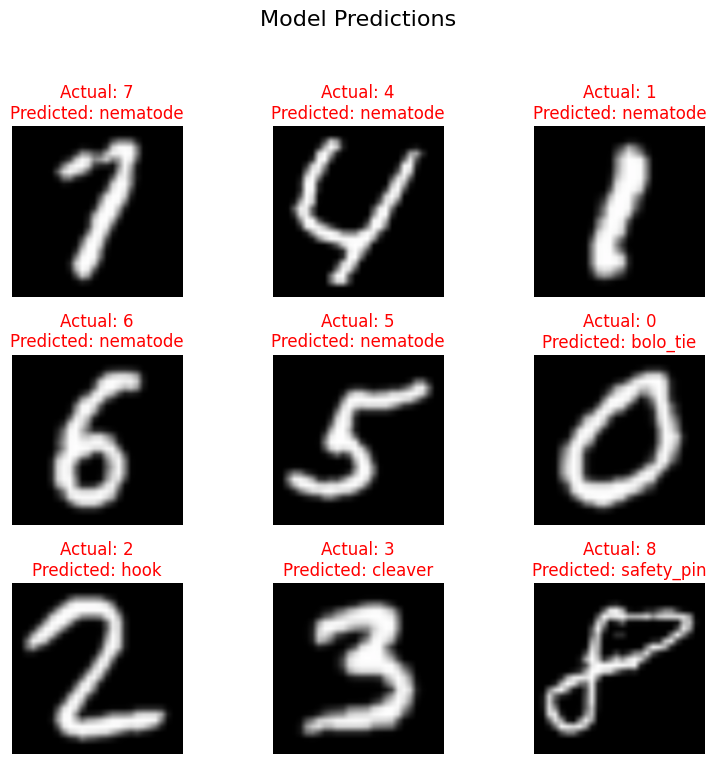

In [8]:
# Visualize the model's predictions on the validation images
helper_utils.show_predictions(mobilenet_model, val_loader, device, class_names)

<br>

Bueno, eso es sorprendente. Un modelo lo suficientemente inteligente como para identificar 1,000 objetos diferentes mira estos números y ve una espátula o un nematodo, entre otras cosas. ¡Parece que el modelo tiene una imaginación muy activa! 

Como puedes ver, las predicciones no están solo un poco erradas; están completamente fuera de contexto. Esto sucede porque el modelo está haciendo todo lo posible para hacer coincidir estas formas desconocidas con los patrones visuales más cercanos que aprendió de su entrenamiento en ImageNet. No tiene el concepto de números, por lo que encuentra lo más parecido dentro de su vocabulario.


Esto ilustra perfectamente el problema central: el conocimiento de un modelo preentrenado es potente pero limitado a su dominio original. Entonces, ¿cómo le enseñas a un modelo experto una nueva habilidad? La solución es una técnica poderosa llamada **aprendizaje por transferencia** (transfer learning). En la siguiente sección, aprenderás cómo tomar el conocimiento existente de este modelo y adaptarlo para identificar correctamente los mismos números que acaba de fallar en reconocer.

## Aprendizaje por Transferencia (Transfer Learning)

Utilizar un modelo preentrenado para la inferencia es potente, pero su verdadero potencial se desbloquea cuando lo adaptas para una tarea nueva y personalizada. Este proceso, llamado **aprendizaje por transferencia**, te permite aprovechar el conocimiento experto de un modelo sobre formas y patrones generales para lograr resultados excelentes en tu conjunto de datos específico con significativamente menos datos y tiempo de entrenamiento.



La idea central es tratar el modelo preentrenado como dos partes distintas:

* El **Extractor de Características** (o "backbone"): Estas son las primeras capas de la red que han aprendido a reconocer características visuales universales como bordes, texturas y formas.

* El **Cabezal Clasificador**: Esta es la capa final (o capas) que toma las características del backbone y realiza la predicción final.



En el aprendizaje por transferencia, siempre reemplazarás el cabezal clasificador original por uno nuevo diseñado para tu número específico de clases. La pregunta principal entonces es: **¿qué parte del extractor de características deberías entrenar?** Esta elección da lugar a tres estrategias principales, cada una de las cuales ofrece un equilibrio diferente entre el tiempo de entrenamiento y el rendimiento. Verás estas estrategias en acción.

### Estrategia 1: Extracción de Características (Entrenar solo el nuevo cabezal)

Este es el enfoque más rápido y eficiente desde el punto de vista computacional. **Congelas** todo el backbone y solo entrenas el nuevo cabezal clasificador. Efectivamente, estás utilizando el modelo preentrenado como un extractor de características fijo, confiando plenamente en su conocimiento existente. Este es un excelente punto de partida, especialmente cuando tu conjunto de datos es pequeño.

[Image showing frozen backbone layers vs trainable classifier head in feature extraction strategy]

Si bien esta estrategia se centra en entrenar *solo* el cabezal clasificador, la habilidad práctica de identificarlo y reemplazarlo es un paso fundamental para **cualquier** enfoque de aprendizaje por transferencia que utilices. El método exacto depende de la arquitectura del modelo, que normalmente sigue uno de dos patrones: un **Atributo Directo** (como en ResNet) o un **Bloque Modular** (como en MobileNet). Ahora explorarás ambos, comenzando con el patrón de Atributo Directo.

#### Atributo Directo

Comencemos con el patrón de Atributo Directo. Para esto, usarás [ResNet18](https://docs.pytorch.org/vision/main/models/generated/torchvision.models.resnet18.html).

* De los [pesos de este modelo en particular](https://docs.pytorch.org/vision/main/models/generated/torchvision.models.resnet18.html#torchvision.models.ResNet18_Weights), usarás `IMAGENET1K_V1`. 
* A continuación, cargarás el modelo `ResNet18` con estos pesos especificados.

In [9]:
# Instancia el modelo ResNet18 y carga los pesos seleccionados
resnet18_model = tv_models.resnet18(weights='IMAGENET1K_V1')

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /home/keras/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:03<00:00, 12.1MB/s]


* Ahora, inspecciona la arquitectura del modelo.
* Para hacer esto, puedes imprimir el modelo completo. La salida será detallada, ya que enumera cada capa de la red.

```
ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  ...
    
  )
  (avgpool): AdaptiveAvgPool2d(output_size=(1, 1))
  (fc): Linear(in_features=512, out_features=1000, bias=True)
)
```

In [10]:
# ### Descomenta y ejecuta la línea de abajo si deseas imprimir la arquitectura del modelo.

print(resnet18_model) 

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

<br>

**Observa estos detalles arquitectónicos clave que determinan cómo modificarás el modelo.**

* Nota cómo todos los componentes principales (`conv1`, `layer1`, `fc`, etc.) son atributos directos del modelo `ResNet` principal. No existe un único bloque de alto nivel llamado `features` que agrupe todas las capas convolucionales. Esta estructura "plana" te indica que el enfoque más sencillo para congelar todos los parámetros a la vez es mediante un único bucle sobre los parámetros del modelo (`resnet18_model.parameters()`).

* En el aprendizaje por transferencia, siempre reemplazas el **cabezal clasificador** final del modelo. Al inspeccionar el final de la salida, puedes identificar la capa final, que es una capa `Linear` llamada `fc`.

* `out_features=1000`: Corresponde a las clases originales de ImageNet. Reemplazarás esta capa para que coincida con el número de clases de tu nueva tarea.

Ahora que comprendes la arquitectura del modelo, comienza **congelando** las capas del modelo preentrenado. Este paso garantiza que el modelo conserve las valiosas características que aprendió de su entrenamiento inicial.

* Itera sobre cada parámetro en `resnet18_model` usando `resnet18_model.parameters()`.
* Para cada `param`, establece `param.requires_grad=False`. Esto evita que se calculen los gradientes para estos parámetros durante el ajuste fino del modelo para tu tarea específica, congelando efectivamente sus pesos.

In [11]:
# Iterar sobre cada parámetro en el modelo resnet18_model
for param in resnet18_model.parameters():
    # Establecer el atributo requires_grad de cada parámetro en False para congelarlo
    param.requires_grad = False

* Tras congelar las capas anteriores, el siguiente paso es modificar el **cabezal clasificador** para adaptarlo a tu nueva tarea. Como identificamos anteriormente, para `ResNet18`, esta es la capa `fc` (totalmente conectada o *fully connected*).

In [12]:
# Acceder a la capa totalmente conectada (fc) del modelo resnet18_model
original_fc_layer = resnet18_model.fc

print("Capa totalmente conectada original del modelo:")
print(original_fc_layer)

Capa totalmente conectada original del modelo:
Linear(in_features=512, out_features=1000, bias=True)


<br>

* El paso final es reemplazar el cabezal clasificador original del modelo por uno nuevo diseñado para tu tarea de clasificación específica. Supongamos que, para tu nueva tarea, el número de clases que deseas es `5`.
    
    * `num_features = original_fc_layer.in_features`: Esto recupera la **dimensión de las características de entrada** de la capa `fc` original (`in_features=512`). Este valor representa el tamaño de salida de las capas del extractor de características preentrenado, y tu nuevo clasificador **debe** ser capaz de aceptar entradas de este tamaño.
    
    * `num_classes=5`: Aquí defines el número de clases para tu nueva tarea.
    
    * `new_fc_layer = nn.Linear(in_features=num_features, out_features=num_classes)`: Se crea una nueva capa `Linear` (totalmente conectada). Está configurada para aceptar `num_features` del backbone congelado y devolver una predicción para cada una de tus `num_classes`.
    
    * `resnet18_model.fc = new_fc_layer`: ¡Aquí es donde ocurre el reemplazo! Asignas directamente tu `new_fc_layer` al atributo `fc` del `resnet18_model`, intercambiando efectivamente el antiguo clasificador de ImageNet por tu clasificador personalizado.

In [13]:
# Obtener el número de características de entrada de la capa totalmente conectada original
# Esto se almacena en el atributo 'in_features' de la capa lineal
num_features = original_fc_layer.in_features

# Definir el número de clases de salida para la nueva tarea de clasificación
num_classes = 5

# Crear una nueva capa totalmente conectada (capa lineal)
new_fc_layer = nn.Linear(in_features=num_features, out_features=num_classes)

# Reemplazar la capa totalmente conectada original de resnet18_model con la new_fc_layer
resnet18_model.fc = new_fc_layer

print("Nueva capa totalmente conectada del modelo:")
print(resnet18_model.fc)

Nueva capa totalmente conectada del modelo:
Linear(in_features=512, out_features=5, bias=True)


<br>

¡Y con eso, has reconfigurado con éxito el modelo `ResNet` para una nueva tarea! Este proceso, que consiste en congelar el extractor de características y cambiar el clasificador, es una piedra angular del aprendizaje por transferencia. Ahora estás listo para aplicar este mismo principio básico al siguiente patrón arquitectónico común: el Bloque Modular.


#### Bloque Modular (Modular Block)

Ahora veamos el patrón de Bloque Modular. Para esto, utilizarás [MobileNetV3](https://docs.pytorch.org/vision/main/models/mobilenetv3.html) Small.

* De los [pesos de este modelo en particular](https://docs.pytorch.org/vision/main/models/generated/torchvision.models.mobilenet_v3_small.html#torchvision.models.MobileNet_V3_Small_Weights), usarás `IMAGENET1K_V1`.
* A continuación, cargarás el modelo `MobileNetV3` Small con estos pesos especificados.

In [14]:
# Instanciar la arquitectura MobileNetV3 Small y cargar los pesos seleccionados
mobilenet_model = tv_models.mobilenet_v3_small(weights='IMAGENET1K_V1')

* Ahora, inspecciona la arquitectura del modelo.
* Para hacerlo, puedes imprimir el modelo completo. La salida será detallada, ya que enumera cada capa de la red.

```
MobileNetV3(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(16, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
      (2): Hardswish()
    )
  ...
  (avgpool): AdaptiveAvgPool2d(output_size=1)
  (classifier): Sequential(
    (0): Linear(in_features=576, out_features=1024, bias=True)
    (1): Hardswish()
    (2): Dropout(p=0.2, inplace=True)
    (3): Linear(in_features=1024, out_features=1000, bias=True)
  )
)
```

In [15]:
# ### Descomenta y ejecuta la línea de abajo si deseas imprimir la arquitectura del modelo.

print(mobilenet_model) 

MobileNetV3(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(16, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
      (2): Hardswish()
    )
    (1): InvertedResidual(
      (block): Sequential(
        (0): Conv2dNormActivation(
          (0): Conv2d(16, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), groups=16, bias=False)
          (1): BatchNorm2d(16, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
          (2): ReLU(inplace=True)
        )
        (1): SqueezeExcitation(
          (avgpool): AdaptiveAvgPool2d(output_size=1)
          (fc1): Conv2d(16, 8, kernel_size=(1, 1), stride=(1, 1))
          (fc2): Conv2d(8, 16, kernel_size=(1, 1), stride=(1, 1))
          (activation): ReLU()
          (scale_activation): Hardsigmoid()
        )
        (2): Conv2dNormActivation(
          (0): Conv2d(16, 16, kernel_size=(1, 1), 

<br>

**Observa estos detalles arquitectónicos clave que determinan cómo modificarás el modelo.**

* **Nota la estructura modular**: Las capas convolucionales están agrupadas dentro de un bloque `Sequential` llamado `features`, y las capas finales de predicción están contenidas dentro de **otro** bloque `Sequential` llamado `classifier`. Esta modularidad significa que congelarás los parámetros iterando sobre los parámetros dentro de features (`mobilenet_model.features.parameters()`) para el backbone y te dirigirás específicamente al clasificador (`mobilenet_model.classifier`) para su modificación.

* Al inspeccionar el final de la salida, puedes identificar la capa de clasificación final como la **última** capa `Linear` (etiquetada como `(3)`) dentro del bloque `Sequential` del `classifier`.

* `out_features=1000`: Corresponde a las clases originales de ImageNet. Reemplazarás esta capa para que coincida con el número de clases de tu nueva tarea.

<br>

Al igual que antes, **congelarás** las capas anteriores. Sin embargo, debido a la estructura modular de `MobileNetV3` Small, te dirigirás específicamente a su bloque `features`.

* Itera sobre cada parámetro en `mobilenet_model.features` utilizando `mobilenet_model.features.parameters()`.
* Para cada `feature_parameter`, establece `feature_parameter.requires_grad = False`.

In [16]:
# Iterar a través de cada parámetro en model.features.parameters()
for feature_parameter in mobilenet_model.features.parameters():
    # Establecer el atributo requires_grad de cada feature_parameter en False
    feature_parameter.requires_grad = False

Como antes, el siguiente paso es modificar el cabezal clasificador. A diferencia del atributo directo `fc` de ResNet, el clasificador de `MobileNetV3` es un bloque `Sequential`.

* Para acceder a la capa lineal final dentro de este bloque (la cual realiza la clasificación real), utiliza `mobilenet_model.classifier[-1]` para seleccionar directamente el último elemento en la secuencia de capas del `classifier`.

In [17]:
# Acceder a la capa de clasificación final del modelo
last_classifier_layer = mobilenet_model.classifier[-1]

print("Capa de salida original del modelo:")
print(last_classifier_layer)

Capa de salida original del modelo:
Linear(in_features=1024, out_features=1000, bias=True)


<br>

Al igual que antes, el paso final consiste en sustituir el cabezal clasificador original del modelo por uno nuevo adaptado a tu tarea de clasificación específica. Supongamos que tu nueva tarea requiere `10` clases. Todo sucede de la misma manera, excepto:

* `mobilenet_model.classifier[-1] = new_classifier`: Dado que el clasificador es un bloque `Sequential`, asignas directamente tu `new_classifier` al último elemento (`[-1]`) de `mobilenet_model.classifier`, intercambiando eficazmente el antiguo clasificador de ImageNet por el tuyo personalizado. 

Como solo se congeló la estructura principal (*backbone*) de `features`, todo el bloque `classifier` (incluyendo todas sus capas) será entrenable durante el proceso de aprendizaje.

In [18]:
# Acceder al atributo in_features de la última capa del clasificador
num_features = last_classifier_layer.in_features

# Definir el número de clases de salida para la nueva tarea de clasificación
num_classes = 10

# Crear una nueva capa lineal para la clasificación
new_classifier = nn.Linear(in_features=num_features, out_features=num_classes)

# Reemplazar la capa de clasificación original por la capa recién creada
mobilenet_model.classifier[-1] = new_classifier

print("Nueva capa de salida del modelo:")
print(mobilenet_model.classifier[-1])

Nueva capa de salida del modelo:
Linear(in_features=1024, out_features=10, bias=True)


<br>

¡Y así es como se prepara un modelo para el aprendizaje por transferencia cuando tiene una arquitectura modular!

#### Entrenando el Cabezal Clasificador

Es hora de poner en práctica la **Estrategia 1 (Extracción de Características)** resolviendo el desafío inicial de `EMNIST`. Utilizarás el `mobilenet_model` que ya preparaste; su nuevo cabezal clasificador de 10 clases encaja perfectamente con las 10 clases de dígitos del conjunto de datos `EMNIST`. Dado que el modelo y los cargadores de datos están listos, el primer paso es definir la función de pérdida y el optimizador.

* Define la función de pérdida y el optimizador.
* `filter(lambda p: p.requires_grad, mobilenet_model.parameters())`: Observa que **solo** estás pasando los parámetros del nuevo *cabezal clasificador* al optimizador.
    * Esto selecciona únicamente los parámetros del modelo que requieren gradientes (es decir, que no están congelados). Dado que solo se congeló el backbone de `features`, esto significa que todo el bloque `classifier` se entrenará para tu tarea específica, lo cual es el principio central de este enfoque de extracción de características.

In [19]:
# Definir la función de pérdida y el optimizador
loss_function = torch.nn.CrossEntropyLoss()
# Optimizar únicamente los parámetros que requieren gradientes para el modelo mobilenet_model
optimizer = torch.optim.SGD(filter(lambda p: p.requires_grad, 
                                   mobilenet_model.parameters()),
                            lr=0.001)

* Finalmente, pasa todos los componentes —el modelo, los cargadores de datos, la función de pérdida y el optimizador— a la función `training_loop` para iniciar el entrenamiento.

In [20]:
# Numero de épocas para el entrenamiento de la nueva cabeza clasificadora
num_epochs = 1

# Start the training.
trained_model = helper_utils.training_loop(
    model=mobilenet_model, 
    trainloader=train_loader, 
    valloader=val_loader, 
    loss_function=loss_function, 
    optimizer=optimizer, 
    num_epochs=num_epochs, 
    device=device
)

Epoch 1/1 [Train]:   0%|          | 0/1000 [00:00<?, ?it/s]

Epoch 1/1 [Val]:   0%|          | 0/250 [00:00<?, ?it/s]


Finished Training!
Final Validation Accuracy: 0.8158


<br>

Con solo una época de entrenamiento, el modelo logró una impresionante precisión de validación superior al 80%.

* Ahora, visualiza las nuevas predicciones del modelo para ver este rendimiento mejorado en acción.
    * Dado que reemplazaste el cabezal clasificador original del modelo por uno entrenado con los dígitos de `EMNIST`, los antiguos nombres de las clases de ImageNet ya no son válidos.

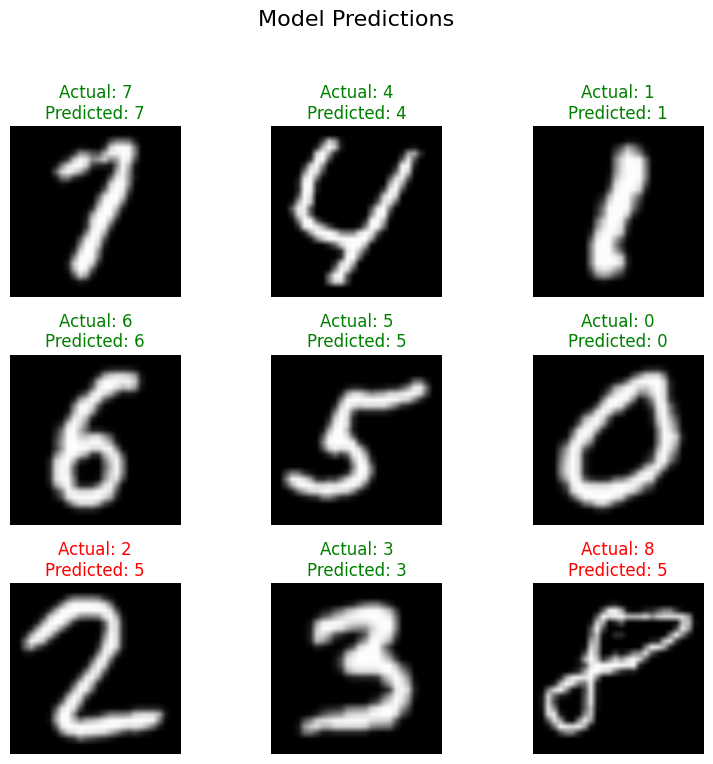

In [21]:
# Definir una lista de nombres de clases para los dígitos de EMNIST (0-9).
emnist_class_names = ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9']

# Visualizar las predicciones del modelo en las imágenes de validación
helper_utils.show_predictions(trained_model, val_loader, device, emnist_class_names)

<br>

Como has visto, entrenar solo el cabezal clasificador es una forma rápida y eficaz de obtener resultados iniciales sólidos. Sin embargo, para llevar el rendimiento de tu modelo aún más lejos, puedes ir más allá de la simple extracción de características y comenzar a ajustar el *backbone* mismo. Esto nos lleva a la segunda estrategia, más potente.

### Estrategia 2: Ajuste Fino o Fine-Tuning (Entrenar el cabezal y las capas superiores)

Esta estrategia, altamente efectiva y popular, sirve como un punto medio, ofreciendo un mejor rendimiento que la extracción de características sin el coste de reentrenar todo el modelo. Cuando decides realizar un ajuste fino, tienes dos opciones principales:

* **Entrenamiento de una sola etapa**: Un enfoque directo en el que descongelas las capas superiores deseadas del *backbone* y las entrenas simultáneamente con el nuevo cabezal clasificador, normalmente utilizando una única tasa de aprendizaje.

* **Entrenamiento de dos etapas**: Un enfoque más cuidadoso y a menudo más eficaz que separa el proceso de entrenamiento en dos etapas distintas para adaptar el modelo gradualmente.



    La estrategia de dos etapas funciona de la siguiente manera:

    * **Etapa 1 (Entrenar el cabezal)**: Comienzas exactamente como lo hiciste en la Estrategia 1, entrenando *solo* el nuevo cabezal clasificador mientras el *backbone* permanece congelado. Esto enseña rápidamente al nuevo cabezal a tomar decisiones basadas en las características generales que proporciona el *backbone*.

    * **Etapa 2 (Descongelar y ajustar)**: Una vez entrenado el cabezal, **descongelas** las últimas capas del *backbone*. Luego, continúas entrenando tanto las capas descongeladas como el cabezal juntos, pero con una tasa de aprendizaje mucho más baja. Este paso crítico permite que los detectores de características de alto nivel más especializados del modelo se adapten suavemente a las particularidades de tu nuevo conjunto de datos sin alterar drásticamente su valioso conocimiento preentrenado.

Ahora, realizarás la potente **estrategia de dos etapas**. Dado que ya has completado la Etapa 1 al entrenar el cabezal clasificador en tu `trained_model` (originalmente `mobilenet_model`), estás perfectamente preparado para continuar. Tomarás ese modelo y realizarás la Etapa 2: descongelar las capas superiores del *backbone* y ajustarlo con una tasa de aprendizaje menor.

#### Descongelar las capas superiores

El primer paso de la Etapa 2 es descongelar las últimas capas del *backbone* del modelo. Las capas iniciales del *backbone* aprendieron a detectar patrones generales como bordes y colores, mientras que las capas posteriores o "superiores" aprendieron características más complejas y de alto nivel. Al descongelar solo estas capas superiores, permites que el modelo adapte sus detectores de características más especializados a las especificidades del conjunto de datos `EMNIST`.

##### Cómo identificar las capas superiores para descongelar

Al igual que para encontrar el cabezal clasificador, identificar las capas superiores requiere inspeccionar la arquitectura del modelo imprimiéndola (`print(model)`). Debes buscar los últimos bloques convolucionales importantes justo antes de la capa de *pooling* y el clasificador final. El enfoque varía ligeramente según la estructura del modelo.

* **Para modelos modulares (como MobileNetV3)**: Buscarás dentro del bloque principal del *backbone*, que en este caso es `features`. Dado que `features` es un módulo `Sequential`, las "capas superiores" son simplemente los últimos bloques de esa secuencia. Observando la arquitectura de `MobileNetV3`, el bloque `features` termina así:
    ```
      ...
      (11): InvertedResidual(...)
      (12): Conv2dNormActivation(...)
    )
    (avgpool): AdaptiveAvgPool2d(output_size=1)
    (classifier): Sequential(...)
    ```
    <br>
    El último bloque, indexado en <code>[12]</code>, es la capa más alta del extractor de características. Una estrategia común de ajuste fino es descongelar solo este bloque, o quizás los últimos dos o tres. Para esta demostración, descongelarás el bloque final.

* **Para modelos planos (como ResNet)**: En una arquitectura como `ResNet`, buscarías los últimos bloques de capas con nombre. Estos suelen ser `layer1`, `layer2`, `layer3` y `layer4`. Las capas superiores serían `layer4`, o podrías optar por descongelar tanto `layer3` como `layer4`. El proceso de investigación es el mismo: imprime el modelo, identifica los bloques finales de extracción de características por su nombre (`model.layer4`) y luego selecciona sus parámetros para descongelarlos.

Ahora que sabes cómo identificar las capas objetivo, procederás a descongelar el último bloque de tu `trained_model` (originalmente `mobilenet_model`).

In [22]:
# ### Descomenta y ejecuta la línea de abajo si deseas imprimir la arquitectura del modelo.

print(trained_model)   

MobileNetV3(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(16, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
      (2): Hardswish()
    )
    (1): InvertedResidual(
      (block): Sequential(
        (0): Conv2dNormActivation(
          (0): Conv2d(16, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), groups=16, bias=False)
          (1): BatchNorm2d(16, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
          (2): ReLU(inplace=True)
        )
        (1): SqueezeExcitation(
          (avgpool): AdaptiveAvgPool2d(output_size=1)
          (fc1): Conv2d(16, 8, kernel_size=(1, 1), stride=(1, 1))
          (fc2): Conv2d(8, 16, kernel_size=(1, 1), stride=(1, 1))
          (activation): ReLU()
          (scale_activation): Hardsigmoid()
        )
        (2): Conv2dNormActivation(
          (0): Conv2d(16, 16, kernel_size=(1, 1), 

In [23]:
# El modelo de la etapa de entrenamiento anterior
fine_tune_model = trained_model

# Descongelar los parámetros del último bloque en la sección 'features'
for param in fine_tune_model.features[12].parameters():
    param.requires_grad = True

* Es una práctica excelente verificar que las capas correctas se hayan congelado y descongelado.

In [24]:
# Verificar que los parámetros de un bloque inicial (p. ej., features[0]) estén congelados
print(f"Los parámetros en features[0] están congelados:       {not fine_tune_model.features[0][0].weight.requires_grad}")

# Verificar que los parámetros de un bloque final (p. ej., features[12]) ahora estén descongelados
print(f"Los parámetros en features[12] están descongelados:    {fine_tune_model.features[12][0].weight.requires_grad}")

# Verificar que el cabezal clasificador permanezca descongelado y sea entrenable
print(f"Los parámetros en el clasificador están descongelados: {fine_tune_model.classifier[-1].weight.requires_grad}")

Los parámetros en features[0] están congelados:       True
Los parámetros en features[12] están descongelados:    True
Los parámetros en el clasificador están descongelados: True


#### Continuación del entrenamiento (Etapa 2)

* Ahora que tienes más capas entrenables, debes crear un nuevo optimizador. Una tasa de aprendizaje (*learning rate*) más baja es esencial para esta etapa. El uso de una tasa de aprendizaje pequeña garantiza que las actualizaciones de los pesos preentrenados sean sutiles y cuidadosas, refinando su conocimiento en lugar de destruirlo.

* El optimizador se configurará nuevamente para actualizar solo los parámetros donde `requires_grad` sea `True`, pero esto ahora incluye tanto el cabezal clasificador como las capas superiores del *backbone* que has descongelado.

In [25]:
# Crear un nuevo optimizador que apunte a todos los parámetros entrenables
optimizer = torch.optim.SGD(
    filter(lambda p: p.requires_grad, fine_tune_model.parameters()),
    lr=1e-5  # Una nueva tasa de aprendizaje más baja para el ajuste fino
)

* Finalmente, pasa todos los componentes —el modelo, los cargadores de datos, la función de pérdida y el optimizador— a la función `training_loop` para iniciar el entrenamiento.

* Esta vez, los gradientes fluirán y actualizarán no solo el cabezal clasificador, sino también las capas superiores del extractor de características.

In [26]:
# Numero de épocas para la etapa de Fine tuning
num_epochs_fine_tune = 1

# Continue training the model
fine_tune_trained_model = helper_utils.training_loop(
    model=fine_tune_model,
    trainloader=train_loader,
    valloader=val_loader,
    loss_function=loss_function,
    optimizer=optimizer,
    num_epochs=num_epochs_fine_tune,
    device=device
)

Epoch 1/1 [Train]:   0%|          | 0/1000 [00:00<?, ?it/s]

Epoch 1/1 [Val]:   0%|          | 0/250 [00:00<?, ?it/s]


Finished Training!
Final Validation Accuracy: 0.8338


<br>

Tras el ajuste fino, dependiendo de cuántas épocas hayas ejecutado el entrenamiento, deberías observar un aumento en la precisión de validación, superando el rendimiento de la primera etapa. Es probable que también hayas notado que cada época tardó más tiempo; esto es normal, ya que el optimizador ahora actualiza los pesos tanto del cabezal como de las capas del *backbone* descongeladas. Esto resalta el compromiso esencial del ajuste fino: invertir más tiempo de computación para alcanzar una mayor precisión.

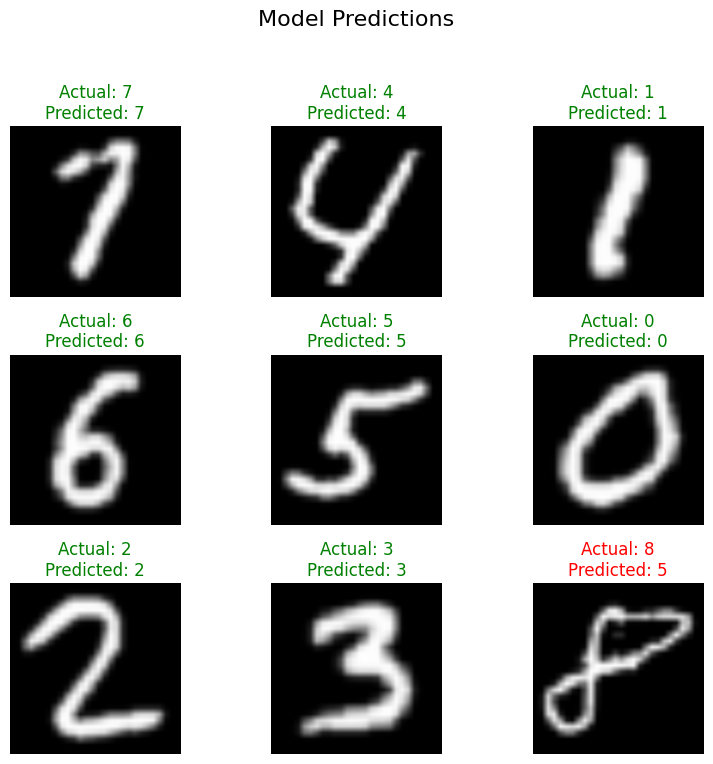

In [27]:
# ### Descomenta y ejecuta la línea de abajo si deseas visualizar las predicciones

# # Visualiza las predicciones del modelo en las imágenes de validación
helper_utils.show_predictions(fine_tune_trained_model, val_loader, device, emnist_class_names)

<br>

Has visto cómo congelar todo el *backbone* y cómo ajustar solo las capas superiores. La estrategia final te otorga un control total al permitir que todo el modelo se adapte a tu nuevo conjunto de datos.

### Estrategia 3: Reentrenamiento Completo (Entrenar todo el modelo)

Este es el enfoque computacionalmente más intensivo y es, esencialmente, una continuación del ajuste fino. Después de reemplazar el cabezal clasificador, descongelas **todas** las capas del *backbone* y reentrenas el modelo completo de principio a fin con tus nuevos datos. Esta estrategia es más efectiva cuando dispones de un conjunto de datos grande y deseas adaptar cada parámetro preentrenado a los patrones específicos de tu nueva tarea.

Para un reentrenamiento completo, todo el modelo debe ser entrenable. Cuando cargas un modelo preentrenado y reemplazas su cabezal clasificador, **todas las capas están en un estado entrenable por defecto**. Solo necesitas congelar capas si así lo decides específicamente, como hiciste en las Estrategias 1 y 2.

Dado que vas a continuar con el modelo de la etapa de ajuste fino anterior, el cual todavía tiene capas congeladas, primero debes descongelar el *backbone* completo.

* Recorrerás todos los parámetros del modelo y volverás a establecer su atributo `requires_grad` en `True`, asegurando que todo el modelo se actualice durante el entrenamiento.

In [28]:
# El modelo de la etapa de ajuste fino anterior
full_retrain_model = fine_tune_trained_model

# Descongelar todos los parámetros del modelo
for param in full_retrain_model.parameters():
    param.requires_grad = True

* Como comprobación rápida, puedes verificar que un parámetro de una capa inicial, que anteriormente estaba congelado, ahora es entrenable y está listo para recibir actualizaciones.

In [29]:
# Verificar que una capa inicial ahora esté descongelada y sea entrenable
print(f"Los parámetros en features[0] están descongelados: {full_retrain_model.features[0][0].weight.requires_grad}")

Los parámetros en features[0] están descongelados: True


#### Entrenamiento Completo

* Para esta etapa final, crearás otro optimizador. A diferencia de las etapas anteriores donde pasabas selectivamente solo los parámetros entrenables al optimizador, esta vez pasarás `full_retrain_model.parameters()`. Este simple cambio instruye al optimizador para calcular gradientes y actualizar los pesos de **cada uno de los parámetros** de todo el modelo, lo cual es el núcleo de la estrategia de reentrenamiento completo.

In [30]:
# The optimizer now targets all parameters in the model
optimizer = torch.optim.SGD(
    full_retrain_model.parameters(),
    lr=1e-4
)


* Finalmente, pasa todos los componentes a la función `training_loop` para iniciar la etapa final del entrenamiento.

    * Durante este proceso, los gradientes fluirán y actualizarán los pesos de **cada una de las capas**, adaptando el modelo completo —desde los detectores de características iniciales hasta el cabezal clasificador final— para tu nueva tarea.

In [31]:
# Numero de épocas para la etapa de reentrenamiento completo
num_epochs_full_retrain = 1

# Continue training the entire model
final_model = helper_utils.training_loop(
    model=full_retrain_model,
    trainloader=train_loader,
    valloader=val_loader,
    loss_function=loss_function,
    optimizer=optimizer,
    num_epochs=num_epochs_full_retrain,
    device=device
)

Epoch 1/1 [Train]:   0%|          | 0/1000 [00:00<?, ?it/s]

Epoch 1/1 [Val]:   0%|          | 0/250 [00:00<?, ?it/s]


Finished Training!
Final Validation Accuracy: 0.8051


<br>

Tras esta etapa final de entrenamiento, es posible que observes otro aumento en la precisión de validación, alcanzando potencialmente el mejor rendimiento de las tres estrategias. Esta etapa también fue la más intensiva a nivel computacional; con cada capa descongelada, el optimizador tuvo que calcular gradientes y actualizar los pesos de todo el modelo.

Esto resalta el compromiso fundamental del enfoque de reentrenamiento completo. Al invertir la cantidad máxima de computación, le das al modelo total libertad para adaptar toda su representación aprendida a tu nuevo conjunto de datos, lo que puede desbloquear el nivel más alto de precisión para tareas complejas.

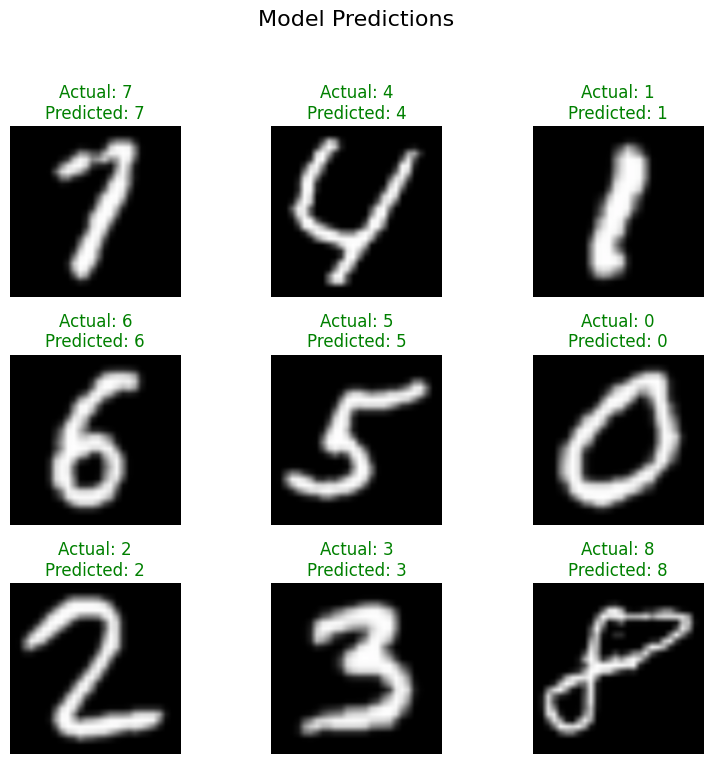

In [32]:
# ### Descomenta y ejecuta la línea de abajo si deseas visualizar las predicciones

# # Visualize the model's predictions on the validation images
helper_utils.show_predictions(final_model, val_loader, device, emnist_class_names)

<br>

Recuerda que el objetivo de demostrar estas diferentes estrategias no era declarar a una como superior a la otra. En su lugar, considera estos tres enfoques —extracción de características, ajuste fino (*fine-tuning*) y reentrenamiento completo— como herramientas potentes y distintas en tu kit de herramientas profesionales. La mejor elección siempre dependerá de las demandas únicas de tu proyecto, incluyendo el tamaño del conjunto de datos, la potencia de cálculo disponible y los requisitos de rendimiento. Ahora estás equipado para tomar esa decisión estratégica y aplicar la técnica adecuada en tu propio trabajo.

## Conclusión

Has navegado con éxito por el flujo de trabajo completo para adaptar un modelo preentrenado a una tarea personalizada. Comenzando con un modelo que producía predicciones sin sentido, aplicaste una serie de técnicas cada vez más potentes para enseñarle una nueva habilidad. No solo has aprendido la teoría, sino que ahora has implementado las tres estrategias principales del aprendizaje por transferencia (*transfer learning*).
Comenzaste con la **extracción de características**, el método más rápido, congelando el *backbone* y entrenando solo un nuevo cabezal clasificador. Luego, pasaste al **ajuste fino (fine-tuning)**, un enfoque equilibrado en el que descongelaste y entrenaste cuidadosamente las capas superiores del *backbone* para obtener un impulso en el rendimiento. Finalmente, exploraste el **reentrenamiento completo**, la estrategia computacionalmente más intensiva, que permite que todo el modelo se adapte a los nuevos datos.

El recorrido por estas estrategias demuestra una lección esencial: no existe un único "mejor" enfoque. Tu elección siempre dependerá de las demandas únicas de tu proyecto. Para un conjunto de datos pequeño o un prototipado rápido, la extracción de características es un excelente punto de partida. Cuando el rendimiento es primordial y dispones de suficientes datos, el ajuste fino o el reentrenamiento completo son opciones más adecuadas. Ahora estás equipado con un kit de herramientas versátil y potente, listo para tomar decisiones estratégicas y aplicar eficazmente el aprendizaje por transferencia a tus propios desafíos de visión artificial.